<a href="https://colab.research.google.com/github/MUBARAK0079/internspark-2/blob/main/loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install imbalanced-learn xgboost -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving loan_prediction.csv to loan_prediction (1).csv


In [ ]:
df = pd.read_csv("loan_prediction.csv")   # Change filename if needed

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
print(df.shape)

df.info()

df.describe(include='all')

(614, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


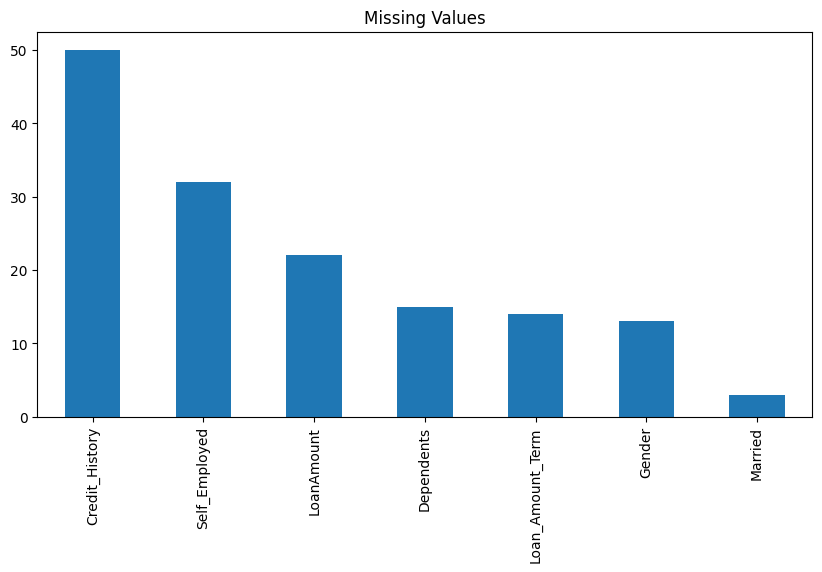

,0
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing[missing>0].plot(kind='bar')
plt.title("Missing Values")
plt.show()

missing[missing>0]

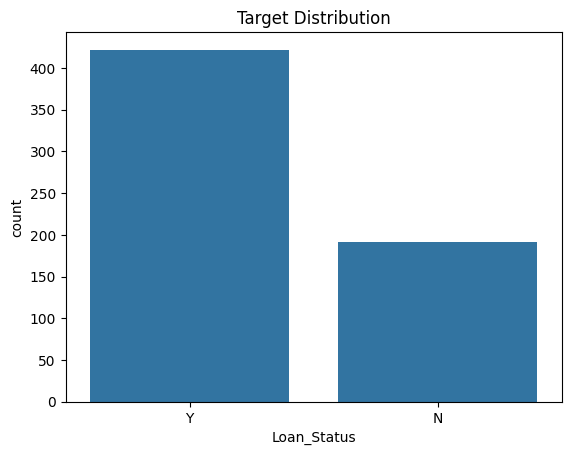

In [ ]:
target_col = "Loan_Status"

df[target_col].value_counts()
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution")
plt.show()

In [ ]:
df[target_col] = df[target_col].map({
    'Y':1,
    'N':0,
    'Approved':1,
    'Rejected':0
})

In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [ ]:
num_cols = X.select_dtypes(include=['int64','float64']).columns

cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

Categorical Columns
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area'],
      dtype='object')


In [ ]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)

(491, 511)


In [ ]:
print("Before SMOTE")

print(y_train.value_counts())
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("After SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
Loan_Status
1    337
0    154
Name: count, dtype: int64
After SMOTE
Loan_Status
1    337
0    337
Name: count, dtype: int64


In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test_processed)

lr_prob = lr.predict_proba(X_test_processed)[:,1]
print("LOGISTIC REGRESSION")

print(classification_report(y_test, lr_pred))

print("ROC AUC:",
      roc_auc_score(y_test, lr_prob))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.89      0.66      0.76        38
           1       0.86      0.96      0.91        85

    accuracy                           0.87       123
   macro avg       0.88      0.81      0.83       123
weighted avg       0.87      0.87      0.86       123

ROC AUC: 0.8687306501547988


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test_processed)

rf_prob = rf.predict_proba(X_test_processed)[:,1]
print("RANDOM FOREST")

print(classification_report(y_test, rf_pred))

print("ROC AUC:",
      roc_auc_score(y_test, rf_prob))

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123

ROC AUC: 0.7986068111455108


In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

xgb_pred = xgb.predict(X_test_processed)

xgb_prob = xgb.predict_proba(X_test_processed)[:,1]
print("XGBOOST")

print(classification_report(y_test, xgb_pred))

print("ROC AUC:",
      roc_auc_score(y_test, xgb_prob))

XGBOOST
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123

ROC AUC: 0.7845201238390094


In [ ]:
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'Random Forest',
             'XGBoost'],

    'ROC-AUC':[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,ROC-AUC
0,Logistic Regression,0.868731
1,Random Forest,0.798607
2,XGBoost,0.784520


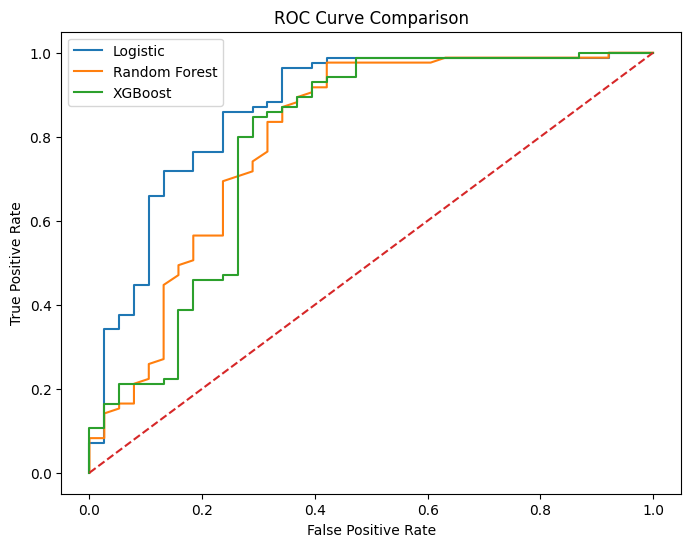

In [ ]:
plt.figure(figsize=(8,6))

for probs, label in [
    (lr_prob,'Logistic'),
    (rf_prob,'Random Forest'),
    (xgb_prob,'XGBoost')
]:

    fpr,tpr,_ = roc_curve(y_test, probs)

    plt.plot(fpr,tpr,label=label)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

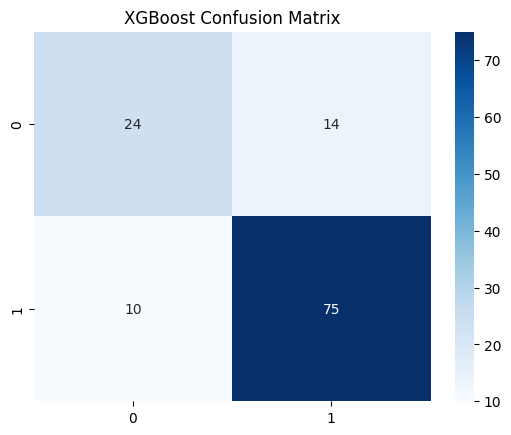

In [ ]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.show()

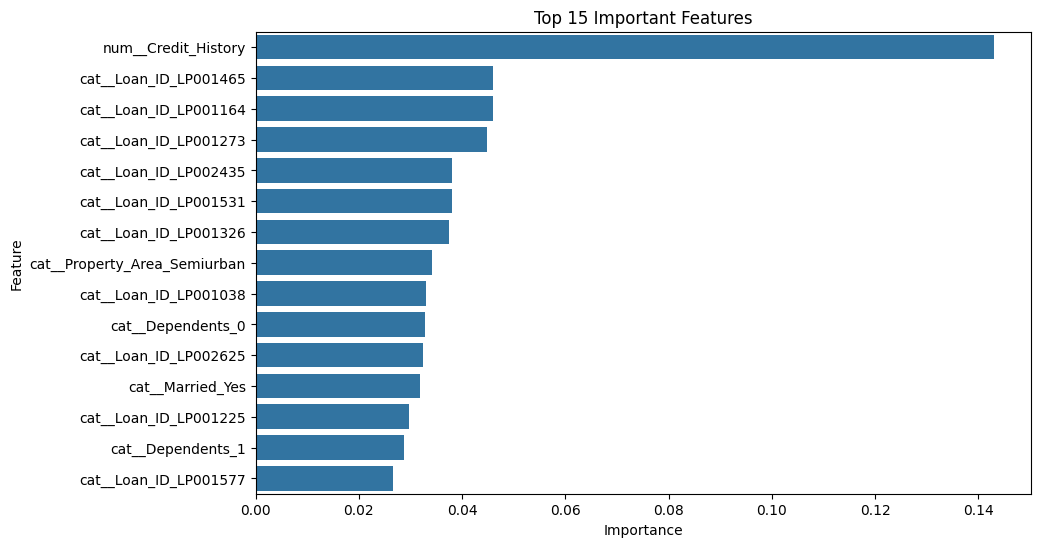

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    'Feature':feature_names,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features")

plt.show()

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    xgb_prob
)

f1_scores = (
    2 * precision * recall
) / (
    precision + recall + 1e-10
)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

print("Best F1 Score:", f1_scores[best_idx])

Best Threshold: 0.16945322
Best F1 Score: 0.898395721875547


In [ ]:
custom_pred = (
    xgb_prob >= best_threshold
).astype(int)

print(classification_report(
    y_test,
    custom_pred
))

              precision    recall  f1-score   support

           0       0.95      0.53      0.68        38
           1       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123

